# EDA

In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["axes.grid"] = True

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 200)

Importación datos

In [2]:
from pathlib import Path

DATA_DIR = Path("datos")

OHLCV_WIDE_PATH = DATA_DIR / "precios_ohlcv_wide.csv"

print(OHLCV_WIDE_PATH)
# Cargar precios OHLCV en formato horizontal
ohlcv_wide = pd.read_csv(OHLCV_WIDE_PATH, parse_dates=True)
ohlcv_wide = ohlcv_wide.set_index("Date")
print("\nPrecios OHLCV en formato horizontal:")
print(ohlcv_wide.head())




datos\precios_ohlcv_wide.csv

Precios OHLCV en formato horizontal:
            Close_AMZN  Close_GOOGL  Close_META  Close_MSFT  Close_NVDA   Close_SPY  Close_TSLA  High_AMZN  High_GOOGL  High_META  High_MSFT  High_NVDA    High_SPY  High_TSLA   Low_AMZN  Low_GOOGL  \
Date                                                                                                                                                                                                   
2014-01-02   19.898500    27.627516   54.284016   30.694443    0.373844  148.580261   10.006667    19.9680   27.742432  54.790047  30.892686   0.376672  149.514378  10.165333  19.701000  27.506891   
2014-01-03   19.822001    27.425976   54.135174   30.487936    0.369365  148.555923    9.970667    20.1355   27.722076  55.216687  30.743999   0.375258  149.132640  10.146000  19.811001  27.424239   
2014-01-06   19.681499    27.731758   56.754623   29.843655    0.374315  148.125412    9.800000    19.8500   27.769980  56.814154  30

Establecemos que ticker vamos a usar

In [3]:
ohlcv_wide.columns = [str(col).strip() for col in ohlcv_wide.columns]

tickers = sorted([
    col.replace("Close_", "")
    for col in ohlcv_wide.columns
    if col.startswith("Close_")
])

print("Tickers detectados:")
print(tickers)

Tickers detectados:
['AMZN', 'GOOGL', 'META', 'MSFT', 'NVDA', 'SPY', 'TSLA']


Comprobamos máximos y mínimos viendo que todo está correcto 

In [4]:
ohlcv_wide.info()

summary_dates = pd.DataFrame({
    "Ticker": tickers,
    "min": [
        ohlcv_wide[f"Close_{ticker}"].dropna().index.min()
        for ticker in tickers
    ],
    "max": [
        ohlcv_wide[f"Close_{ticker}"].dropna().index.max()
        for ticker in tickers
    ],
    "count": [
        ohlcv_wide[f"Close_{ticker}"].dropna().count()
        for ticker in tickers
    ],
})

summary_dates

<class 'pandas.core.frame.DataFrame'>
Index: 2640 entries, 2014-01-02 to 2024-06-28
Data columns (total 35 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Close_AMZN    2640 non-null   float64
 1   Close_GOOGL   2640 non-null   float64
 2   Close_META    2640 non-null   float64
 3   Close_MSFT    2640 non-null   float64
 4   Close_NVDA    2640 non-null   float64
 5   Close_SPY     2640 non-null   float64
 6   Close_TSLA    2640 non-null   float64
 7   High_AMZN     2640 non-null   float64
 8   High_GOOGL    2640 non-null   float64
 9   High_META     2640 non-null   float64
 10  High_MSFT     2640 non-null   float64
 11  High_NVDA     2640 non-null   float64
 12  High_SPY      2640 non-null   float64
 13  High_TSLA     2640 non-null   float64
 14  Low_AMZN      2640 non-null   float64
 15  Low_GOOGL     2640 non-null   float64
 16  Low_META      2640 non-null   float64
 17  Low_MSFT      2640 non-null   float64
 18  Low_NVDA      2640

,Ticker,min,max,count
0,AMZN,2014-01-02,2024-06-28,2640
1,GOOGL,2014-01-02,2024-06-28,2640
2,META,2014-01-02,2024-06-28,2640
3,MSFT,2014-01-02,2024-06-28,2640
4,NVDA,2014-01-02,2024-06-28,2640
5,SPY,2014-01-02,2024-06-28,2640
6,TSLA,2014-01-02,2024-06-28,2640


## Análisis de precios

Aunque el gráfico de precios absolutos permite visualizar la evolución histórica de cada activo, no es adecuado para comparar directamente cuál ha sido mejor inversión. Cada acción parte de un nivel de precio distinto y puede haber sufrido splits, cambios corporativos o diferencias estructurales en su cotización. Por ello, un precio más alto no implica necesariamente mayor rentabilidad. Para comparar correctamente los activos es necesario transformar los precios en retornos porcentuales, precios normalizados con base 100 o rentabilidades acumuladas, ya que estas medidas muestran el crecimiento relativo de una inversión inicial equivalente en cada activo.

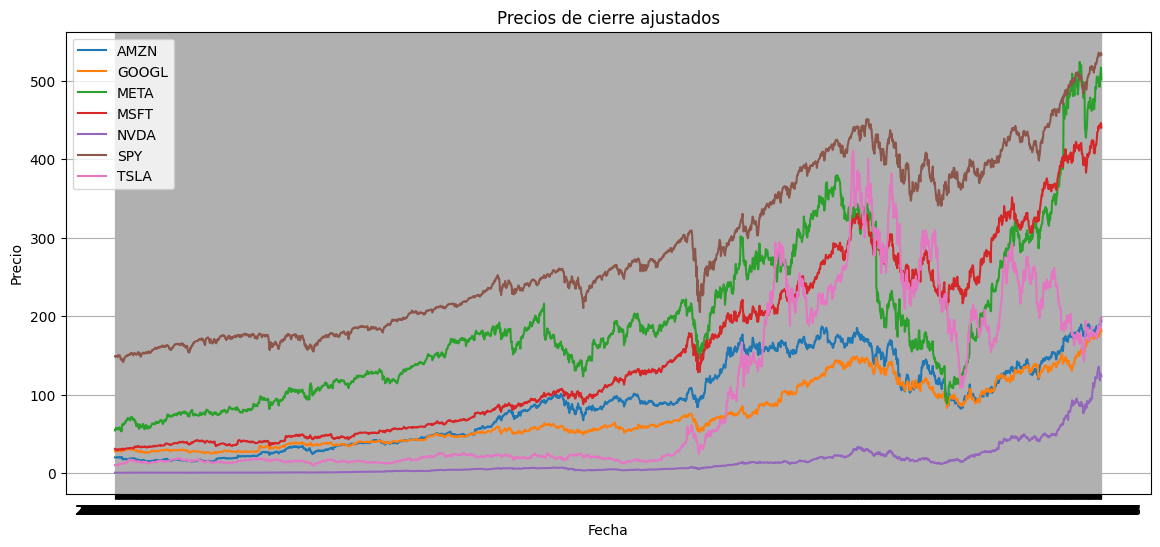

In [5]:
# Precios absolutos de cierre ajustados
plt.figure(figsize=(14, 6))

for ticker in tickers:
    columna = f"Close_{ticker}"
    plt.plot(ohlcv_wide.index, ohlcv_wide[columna], label=ticker)

plt.title("Precios de cierre ajustados")
plt.xlabel("Fecha")
plt.ylabel("Precio")
plt.legend()
plt.grid(True)
plt.show()

En términos generales, normalizar una serie temporal permite comparar la evolución relativa de varios activos partiendo de una misma base inicial, por ejemplo 100. Esto elimina el problema de comparar precios absolutos, ya que todos los activos empiezan desde el mismo punto y se observa cuánto habría crecido una inversión equivalente en cada uno. Sin embargo, la normalización no siempre garantiza una comparación visual clara: si uno de los activos tiene un crecimiento extremadamente superior al resto, domina la escala del gráfico y hace que las demás series parezcan casi planas. Por tanto, los gráficos normalizados son útiles para interpretar crecimiento relativo, pero deben complementarse con tablas de rentabilidad, escala logarítmica, volatilidad y drawdown para obtener una comparación financiera más completa.

,Close_AMZN,Close_GOOGL,Close_META,Close_MSFT,Close_NVDA,Close_SPY,Close_TSLA,High_AMZN,High_GOOGL,High_META,High_MSFT,High_NVDA,High_SPY,High_TSLA,Low_AMZN,Low_GOOGL,Low_META,Low_MSFT,Low_NVDA,Low_SPY,Low_TSLA,Open_AMZN,Open_GOOGL,Open_META,Open_MSFT,Open_NVDA,Open_SPY,Open_TSLA,Volume_AMZN,Volume_GOOGL,Volume_META,Volume_MSFT,Volume_NVDA,Volume_SPY,Volume_TSLA
Date,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2014-01-02,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000
2014-01-03,99.615549,99.270510,99.725809,99.327218,98.802044,99.983620,99.640237,100.838840,99.926627,100.778681,99.518700,99.624550,99.744681,99.809816,100.558350,99.699525,100.627400,98.652275,99.363890,100.082226,101.398836,99.872110,99.958755,100.346501,99.598384,99.811578,99.592367,100.133511,103.386659,91.506533,88.542094,101.640757,99.707796,68.031352,75.867753
2014-01-06,98.909461,100.377313,104.551262,97.228201,100.126123,99.693870,97.934707,99.409054,100.099301,103.694297,98.636354,100.125168,99.722939,98.635892,98.578749,99.835776,99.741640,97.331538,99.745556,99.780814,99.106104,99.260276,99.780363,99.252217,98.661308,99.434683,99.733685,100.133511,148.311348,97.139563,159.397622,142.345963,157.441213,90.296723,86.631439
2014-01-07,100.015078,102.312414,105.867277,97.981678,101.765466,100.306161,99.506983,99.777142,101.962868,106.030399,97.566823,101.376736,99.847894,98.635892,100.068526,101.163981,105.591421,97.601057,101.335898,100.257581,99.112927,99.057173,100.855249,105.234337,97.269063,100.753785,99.516270,98.544727,89.624848,140.144943,178.739452,116.879623,128.142350,72.004708,81.347360
2014-01-08,100.992538,102.525327,106.433895,96.232460,103.152634,100.328015,100.786133,100.911454,102.645489,105.776860,96.630966,102.878643,99.869611,100.800113,100.512663,102.258493,105.609863,95.902930,102.671796,100.224684,101.508006,99.917249,102.737882,105.051943,96.385502,101.758838,99.711925,99.365819,108.359061,123.119578,131.222928,195.779931,118.493456,80.729524,99.592787


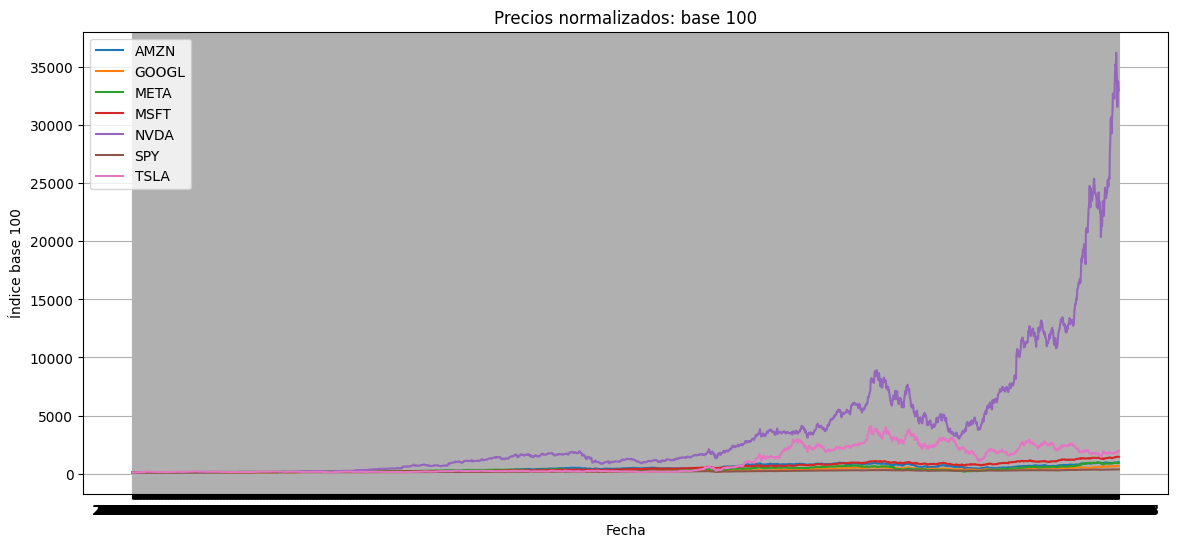

In [6]:
normalized_prices = ohlcv_wide / ohlcv_wide.iloc[0] * 100
display(normalized_prices.head())

plt.figure(figsize=(14, 6))

for ticker in tickers:
    columna = f"Close_{ticker}"
    plt.plot(normalized_prices.index, normalized_prices[columna], label=ticker)

plt.title("Precios normalizados: base 100")
plt.xlabel("Fecha")
plt.ylabel("Índice base 100")
plt.legend()
plt.show()

## Retornos simples

Los retornos simples miden cuánto ha cambiado el precio de un activo en porcentaje de un día al siguiente. No miran el cambio en dólares/euros, sino el cambio relativo. Por ejemplo, si una acción pasa de 100 a 105, el retorno simple es del 5%; si pasa de 100 a 95, el retorno es del -5%. En finanzas se usan más los retornos que los precios porque permiten comparar activos con precios muy distintos.

Formalmente:

retorno_t = Close_t / Close_{t-1} - 1

,count,mean,std,min,25%,50%,75%,max,mean_%,std_%,min_%,max_%
AMZN,2639.0,0.001075,0.020683,-0.140494,-0.008666,0.001078,0.011187,0.141311,0.107501,2.068266,-14.049438,14.131126
GOOGL,2639.0,0.000866,0.017576,-0.116342,-0.007388,0.001121,0.009400,0.162585,0.086628,1.757585,-11.634158,16.258450
META,2639.0,0.001126,0.023709,-0.263901,-0.009455,0.001097,0.012379,0.232824,0.112646,2.370855,-26.390086,23.282409
MSFT,2639.0,0.001151,0.016847,-0.147390,-0.006678,0.000868,0.009793,0.142169,0.115126,1.684656,-14.739037,14.216915
NVDA,2639.0,0.002628,0.029417,-0.187559,-0.011491,0.002386,0.016569,0.298067,0.262782,2.941682,-18.755873,29.806654
SPY,2639.0,0.000544,0.010876,-0.109424,-0.003673,0.000615,0.005757,0.090603,0.054355,1.087622,-10.942363,9.060314
TSLA,2639.0,0.001741,0.034983,-0.210628,-0.015703,0.001057,0.018313,0.198949,0.174125,3.498305,-21.062824,19.894859


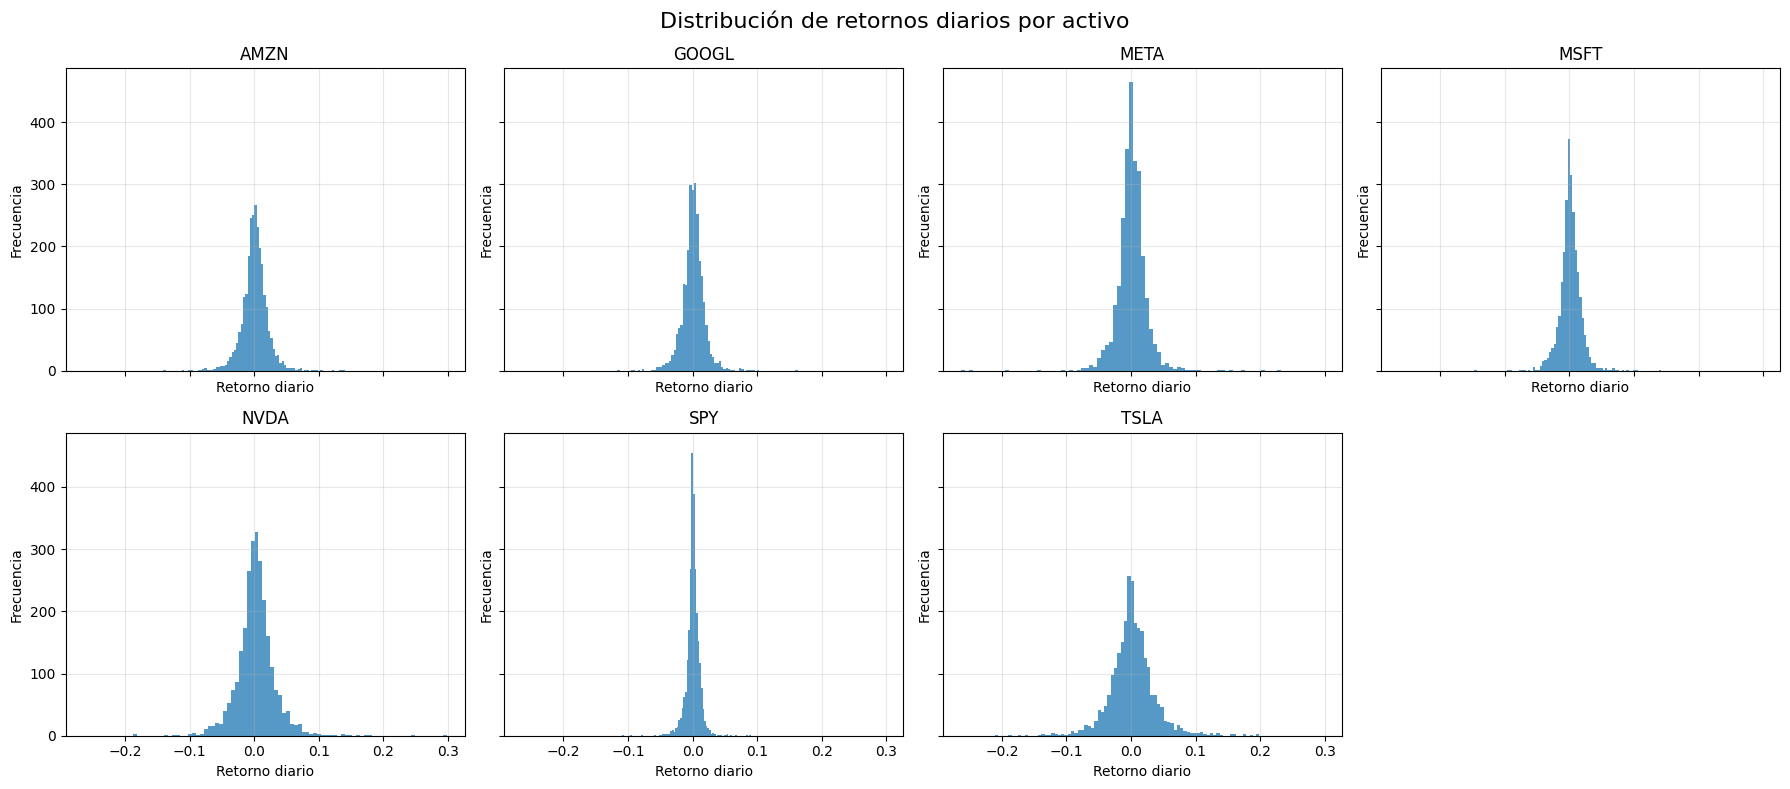

C:\Users\Usuario\AppData\Local\Temp\ipykernel_26836\1673979546.py:38: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


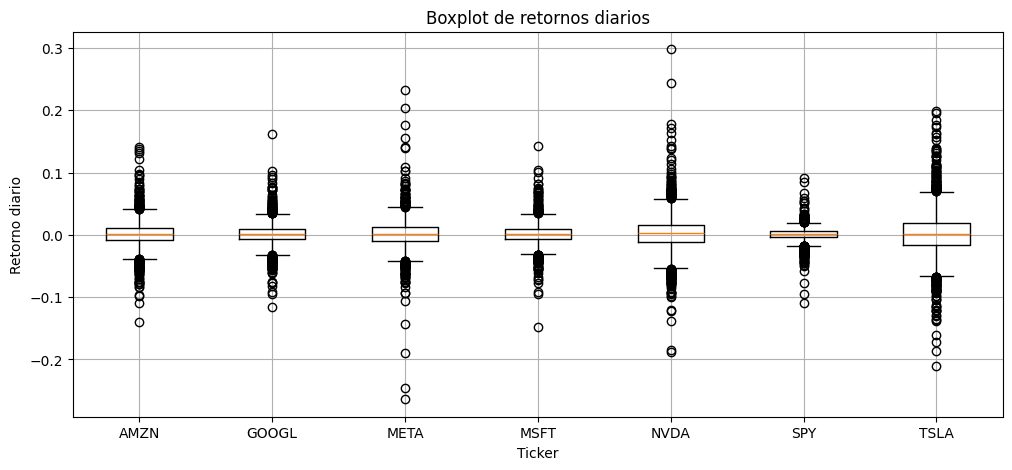

In [7]:
close_cols = [f"Close_{ticker}" for ticker in tickers]

returns_wide = ohlcv_wide[close_cols].pct_change()
returns_wide.columns = tickers

returns_summary = returns_wide.describe().T

returns_summary["mean_%"] = returns_summary["mean"] * 100
returns_summary["std_%"] = returns_summary["std"] * 100
returns_summary["min_%"] = returns_summary["min"] * 100
returns_summary["max_%"] = returns_summary["max"] * 100

display(returns_summary)

fig, axes = plt.subplots(2, 4, figsize=(18, 8), sharex=True, sharey=True)

axes = axes.flatten()

for i, ticker in enumerate(tickers):
    axes[i].hist(
        returns_wide[ticker].dropna(),
        bins=80,
        alpha=0.75
    )
    axes[i].set_title(ticker)
    axes[i].set_xlabel("Retorno diario")
    axes[i].set_ylabel("Frecuencia")
    axes[i].grid(True, alpha=0.3)

for j in range(len(tickers), len(axes)):
    axes[j].axis("off")

fig.suptitle("Distribución de retornos diarios por activo", fontsize=16)
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 5))
plt.boxplot(
    [returns_wide[ticker].dropna() for ticker in tickers],
    labels=tickers,
    showfliers=True
)
plt.title("Boxplot de retornos diarios")
plt.xlabel("Ticker")
plt.ylabel("Retorno diario")
plt.show()

## Retornos logarítmicos

Los retornos logarítmicos suelen preferirse en análisis financiero porque tienen una propiedad muy cómoda: son aditivos en el tiempo. Es decir, si calculas el retorno logarítmico de hoy, mañana y pasado, puedes sumarlos para obtener el retorno logarítmico total del periodo. Con los retornos simples esto no funciona así directamente, porque hay que multiplicar los factores de crecimiento. Por ejemplo, si un activo sube un 10% y luego baja un 10%, no vuelve exactamente al punto inicial: pasa de 100 a 110 y después a 99. Los retornos logarítmicos manejan mejor esta composición temporal y por eso son muy usados en modelos estadísticos, series temporales y análisis de volatilidad.

Además, los retornos logarítmicos suelen tener propiedades más convenientes para trabajar matemáticamente: son más simétricos para subidas y bajadas, se aproximan mucho al retorno simple cuando los cambios diarios son pequeños y tienden a comportarse mejor en ciertos modelos financieros. Dicho esto, no significa que los retornos simples estén mal. Para interpretar rentabilidades reales de una inversión, el retorno simple es más intuitivo: “he ganado un 5%”. Para modelar, agregar periodos y hacer análisis estadístico, el retorno logarítmico suele ser más limpio.

In [8]:
close_cols = [f"Close_{ticker}" for ticker in tickers]

close_wide = ohlcv_wide[close_cols].copy()
close_wide.columns = tickers

log_returns_wide = np.log(close_wide / close_wide.shift(1))

ticker_example = "SPY"

comparison_returns = pd.DataFrame({
    "simple_return": returns_wide[ticker_example],
    "log_return": log_returns_wide[ticker_example]
})

comparison_returns["difference"] = (
    comparison_returns["simple_return"] - comparison_returns["log_return"]
)

display(comparison_returns.describe())

,simple_return,log_return,difference
count,2639.000000,2639.000000,2639.000000
mean,0.000544,0.000484,0.000060
std,0.010876,0.010913,0.000235
min,-0.109424,-0.115886,0.000000
25%,-0.003673,-0.003680,0.000002
50%,0.000615,0.000615,0.000011
75%,0.005757,0.005740,0.000046
max,0.090603,0.086731,0.006463


## Rentabilidad acumulada

Simular inversión inicial

In [9]:
cumulative_returns = (1 + returns_wide.fillna(0)).cumprod()

display(cumulative_returns.head())

,AMZN,GOOGL,META,MSFT,NVDA,SPY,TSLA
Date,,,,,,,
2014-01-02,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
2014-01-03,0.996155,0.992705,0.997258,0.993272,0.988020,0.999836,0.996402
2014-01-06,0.989095,1.003773,1.045513,0.972282,1.001261,0.996939,0.979347
2014-01-07,1.000151,1.023124,1.058673,0.979817,1.017655,1.003062,0.995070
2014-01-08,1.009925,1.025253,1.064339,0.962325,1.031526,1.003280,1.007861


,total_return,total_return_%
NVDA,329.299745,32929.974477
TSLA,18.774816,1877.481635
MSFT,13.335968,1333.596790
AMZN,8.711787,871.178710
META,8.235169,823.516888
GOOGL,5.546524,554.652406
SPY,2.587313,258.731343


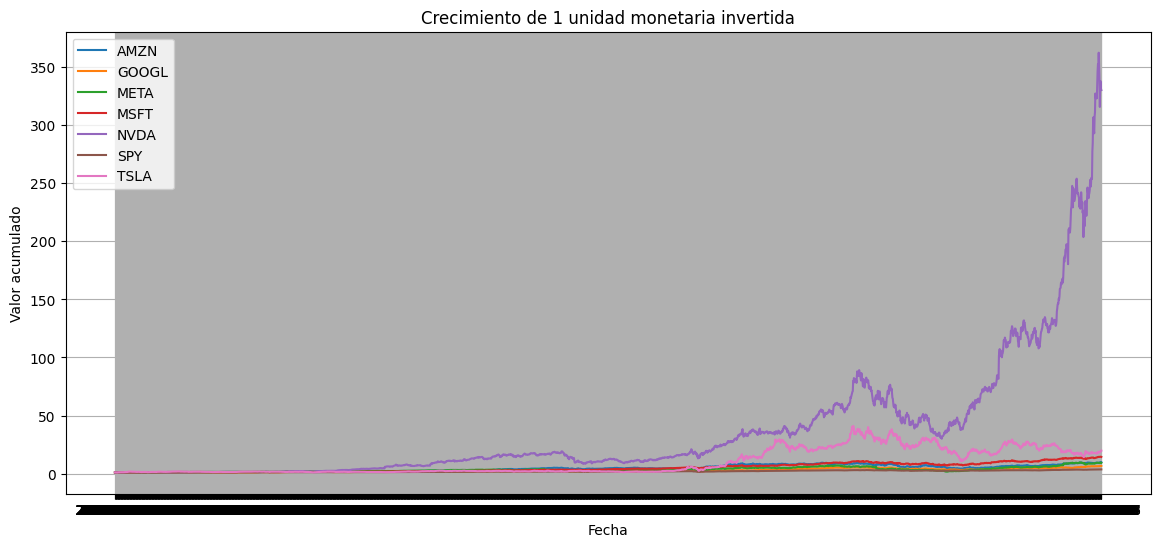

In [10]:
total_return = cumulative_returns.iloc[-1] - 1

total_return_df = pd.DataFrame({
    "total_return": total_return,
    "total_return_%": total_return * 100
}).sort_values("total_return_%", ascending=False)

display(total_return_df)

plt.figure(figsize=(14, 6))

for ticker in tickers:
    plt.plot(cumulative_returns.index, cumulative_returns[ticker], label=ticker)

plt.title("Crecimiento de 1 unidad monetaria invertida")
plt.xlabel("Fecha")
plt.ylabel("Valor acumulado")
plt.legend()
plt.show()



## Medias móviles

Las medias móviles son una herramienta básica para suavizar una serie de precios y observar mejor su tendencia. En lugar de mirar únicamente el precio de hoy, que puede estar afectado por ruido diario, se calcula el promedio de los últimos N días. Por ejemplo, una media móvil de 20 días resume el comportamiento reciente del precio durante aproximadamente un mes bursátil. Esto permite distinguir mejor si el activo está siguiendo una tendencia alcista, bajista o lateral.

La idea intuitiva es sencilla: una media móvil corta, como la de 10 o 20 días, reacciona rápido a los cambios recientes del mercado; una media móvil larga, como la de 100 o 200 días, reacciona más lentamente y representa una tendencia más estructural. Por eso, cuando el precio está por encima de sus medias móviles, suele interpretarse como una señal de fortaleza; cuando está por debajo, puede interpretarse como debilidad. No es una regla infalible, pero ayuda a convertir el movimiento visual del precio en información cuantificable.

También se usan mucho los cruces de medias móviles. Si una media corta supera a una media larga, se suele interpretar como una posible señal de tendencia positiva, porque el precio reciente está ganando fuerza frente a su comportamiento de más largo plazo. Si ocurre lo contrario, puede interpretarse como pérdida de momentum. En un proyecto de Machine Learning financiero, las medias móviles no se usan solo para dibujar gráficos, sino también como variables: distancia del precio a la media, pendiente de la media, cruce entre medias o posición relativa del precio frente a distintos horizontes temporales. Así el modelo puede aprender patrones relacionados con tendencia y momentum.

,Close_AMZN,Close_GOOGL,Close_META,Close_MSFT,Close_NVDA,Close_SPY,Close_TSLA,High_AMZN,High_GOOGL,High_META,High_MSFT,High_NVDA,High_SPY,High_TSLA,Low_AMZN,Low_GOOGL,Low_META,Low_MSFT,Low_NVDA,Low_SPY,Low_TSLA,Open_AMZN,Open_GOOGL,Open_META,Open_MSFT,Open_NVDA,Open_SPY,Open_TSLA,Volume_AMZN,Volume_GOOGL,Volume_META,Volume_MSFT,Volume_NVDA,Volume_SPY,Volume_TSLA,SMA_10_AMZN,SMA_10_GOOGL,SMA_10_META,SMA_10_MSFT,SMA_10_NVDA,SMA_10_SPY,SMA_10_TSLA,SMA_20_AMZN,SMA_20_GOOGL,SMA_20_META,SMA_20_MSFT,SMA_20_NVDA,SMA_20_SPY,SMA_20_TSLA,SMA_50_AMZN,SMA_50_GOOGL,SMA_50_META,SMA_50_MSFT,SMA_50_NVDA,SMA_50_SPY,SMA_50_TSLA,SMA_100_AMZN,SMA_100_GOOGL,SMA_100_META,SMA_100_MSFT,SMA_100_NVDA,SMA_100_SPY,SMA_100_TSLA,SMA_200_AMZN,SMA_200_GOOGL,SMA_200_META,SMA_200_MSFT,SMA_200_NVDA,SMA_200_SPY,SMA_200_TSLA
Date,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2014-01-02,19.898500,27.627516,54.284016,30.694443,0.373844,148.580261,10.006667,19.9680,27.742432,54.790047,30.892686,0.376672,149.514378,10.165333,19.701000,27.506891,53.768064,30.644881,0.370544,148.222861,9.770000,19.940001,27.685593,54.403084,30.851383,0.375258,149.441264,9.986667,42756000,72783144,43195500,30632200,260092000,119636900,92826000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2014-01-03,19.822001,27.425976,54.135174,30.487936,0.369365,148.555923,9.970667,20.1355,27.722076,55.216687,30.743999,0.375258,149.132640,10.146000,19.811001,27.424239,54.105405,30.231873,0.368187,148.344738,9.906667,19.914499,27.674174,54.591591,30.727479,0.374551,148.832092,10.000000,44204000,66601332,38246200,31134800,259332000,81390600,70425000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2014-01-06,19.681499,27.731758,56.754623,29.843655,0.374315,148.125412,9.800000,19.8500,27.769980,56.814154,30.471419,0.377144,149.100133,10.026667,19.421000,27.461718,53.629149,29.827134,0.369601,147.897978,9.682667,19.792500,27.624785,53.996267,30.438378,0.373137,149.043280,10.000000,63412000,70701228,68852600,43603700,409492000,108028200,80416500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2014-01-07,19.901501,28.266378,57.469009,30.074930,0.380444,149.035156,9.957333,19.9235,28.286979,58.094105,30.141012,0.381858,149.286958,10.026667,19.714500,27.827066,56.774463,29.909728,0.375494,148.604655,9.683333,19.752001,27.922374,57.250725,30.008851,0.378087,148.718372,9.841333,38320000,102001896,77207400,35802800,333288000,86144200,75511500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2014-01-08,20.096001,28.325201,57.776592,29.538017,0.385630,149.067627,10.085333,20.1500,28.476355,57.955191,29.851901,0.387515,149.319428,10.246667,19.802000,28.128132,56.784379,29.389339,0.380444,148.555893,9.917333,19.923500,28.443592,57.151497,29.736260,0.381858,149.010762,9.923333,46330000,89610300,56682400,59971700,308192000,96582300,92448000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2014-12-22,15.327000,26.396830,80.815796,40.717068,0.498581,171.814423,14.840000,15.3680,26.430056,81.252372,40.835875,0.498581,171.814423,14.937333,15.097000,25.816128,79.377089,40.487938,0.487784,170.978005,14.550667,15.097000,25.817122,79.456468,40.547342,0.489463,171.218160,14.666667,80076000,66390000,31395800,26566000,148976000,148318900,71991000,15.18600,25.812559,77.005698,39

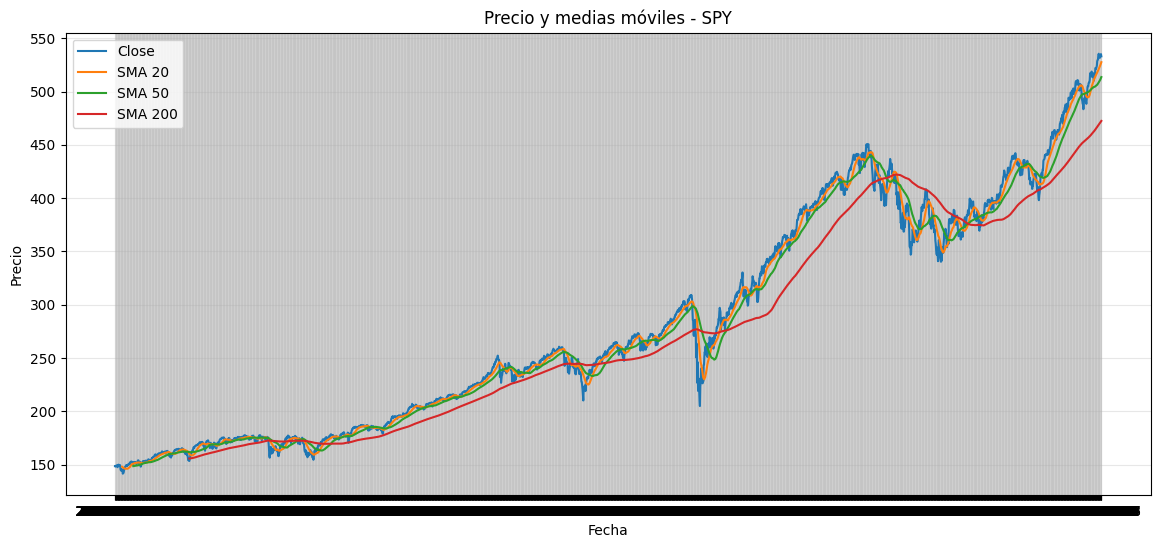

,Close_SPY,SMA_20_SPY,price_vs_sma_20_SPY
Date,,,
2014-01-30,145.582947,148.029949,-0.016530
2014-01-31,144.730103,147.837441,-0.021019
2014-02-03,141.472916,147.483291,-0.040753
2014-02-04,142.463867,147.200214,-0.032176
2014-02-05,142.285202,146.862716,-0.031169


,Close_SPY,SMA_20_SPY,SMA_50_SPY,trend_signal_sma20_50_SPY
Date,,,,
2014-03-14,149.993607,150.888733,148.600245,1
2014-03-17,151.350098,150.982549,148.655641,1
2014-03-18,152.430389,151.121445,148.733131,1
2014-03-19,151.618210,151.269282,148.802987,1
2014-03-20,152.503525,151.417522,148.872354,1


In [11]:
close_cols = [f"Close_{ticker}" for ticker in tickers]

for window in [10, 20, 50, 100, 200]:
    sma = ohlcv_wide[close_cols].rolling(window).mean()
    sma.columns = [f"SMA_{window}_{ticker}" for ticker in tickers]

    ohlcv_wide = pd.concat([ohlcv_wide, sma], axis=1)

display(ohlcv_wide.head(250))

ticker_example = "SPY"

plt.figure(figsize=(14, 6))

plt.plot(ohlcv_wide.index, ohlcv_wide[f"Close_{ticker_example}"], label="Close")
plt.plot(ohlcv_wide.index, ohlcv_wide[f"SMA_20_{ticker_example}"], label="SMA 20")
plt.plot(ohlcv_wide.index, ohlcv_wide[f"SMA_50_{ticker_example}"], label="SMA 50")
plt.plot(ohlcv_wide.index, ohlcv_wide[f"SMA_200_{ticker_example}"], label="SMA 200")

plt.title(f"Precio y medias móviles - {ticker_example}")
plt.xlabel("Fecha")
plt.ylabel("Precio")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

for window in [10, 20, 50, 100, 200]:
    for ticker in tickers:
        ohlcv_wide[f"price_vs_sma_{window}_{ticker}"] = (
            ohlcv_wide[f"Close_{ticker}"] / ohlcv_wide[f"SMA_{window}_{ticker}"] - 1
        )

display(
    ohlcv_wide[
        [
            f"Close_{ticker_example}",
            f"SMA_20_{ticker_example}",
            f"price_vs_sma_20_{ticker_example}",
        ]
    ].dropna().head()
)

for ticker in tickers:
    ohlcv_wide[f"trend_signal_sma20_50_{ticker}"] = np.where(
        ohlcv_wide[f"SMA_20_{ticker}"] > ohlcv_wide[f"SMA_50_{ticker}"],
        1,
        0
    )

display(
    ohlcv_wide[
        [
            f"Close_{ticker_example}",
            f"SMA_20_{ticker_example}",
            f"SMA_50_{ticker_example}",
            f"trend_signal_sma20_50_{ticker_example}",
        ]
    ].dropna().head()
)